# 🌱 TP IA Appliquée — Prédiction des Récoltes au Burundi
**Université Polytechnique de Gitega — Bac4 Génie Logiciel**

Ce notebook couvre les exercices 1 à 6 du TP : exploration, prétraitement, modélisation ML et prédiction.

## 📦 Imports et Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)
import pickle, os

plt.rcParams['figure.facecolor'] = '#faf7f0'
plt.rcParams['axes.facecolor']   = '#faf7f0'
print('✅ Imports OK')

✅ Imports OK


---
## 📊 Exercice 1 — Chargement, Exploration et Qualité des Données
**Objectif :** Charger le dataset, comprendre sa structure, identifier les problèmes de qualité.

### Q1 — Structure du dataset

In [2]:
df = pd.read_csv('agriculture_burundi.csv')
print(f'Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'Période couverte : {df["annee"].min()} – {df["annee"].max()}')
print(f'Provinces ({df["province"].nunique()}) : {sorted(df["province"].unique())}')
print(f'Cultures ({df["culture"].nunique()}) : {sorted(df["culture"].unique())}')
df.head(5)

Dimensions : 1620 lignes × 14 colonnes
Période couverte : 2015 – 2023
Provinces (15) : ['Bubanza', 'Bujumbura Rural', 'Bururi', 'Cankuzo', 'Cibitoke', 'Gitega', 'Kayanza', 'Kirundo', 'Makamba', 'Muramvya', 'Muyinga', 'Mwaro', 'Ngozi', 'Rutana', 'Ruyigi']
Cultures (6) : ['Bananier', 'Haricot', 'Manioc', 'Maïs', 'Patate douce', 'Sorgho']


,annee,saison,province,culture,altitude_m,pluviometrie_mm,temperature_moy_C,superficie_ha,utilisation_engrais,acces_irrigation,nb_menages,rendement_t_ha,production_totale_t,bonne_recolte
0,2015,A,Bujumbura Rural,Maïs,881,NaN,23.9,1.33,1.0,1,154,2.14,2.85,1.0
1,2015,A,Bujumbura Rural,Haricot,803,955.4,22.1,3.25,0.0,0,16,0.64,2.08,1.0
2,2015,A,Bujumbura Rural,Manioc,835,1060.3,24.9,1.71,1.0,1,103,13.38,22.88,1.0
3,2015,A,Bujumbura Rural,Patate douce,848,760.3,23.8,2.94,0.0,1,64,6.94,20.40,1.0
4,2015,A,Bujumbura Rural,Sorgho,837,1126.8,23.1,3.94,0.0,0,56,0.89,3.51,1.0


### Q2 — Types de données

In [3]:
print(df.dtypes)
# Observation : bonne_recolte est float64 à cause des NaN (devrait être int binaire)

annee                    int64
saison                     str
province                   str
culture                    str
altitude_m               int64
pluviometrie_mm        float64
temperature_moy_C      float64
superficie_ha          float64
utilisation_engrais    float64
acces_irrigation         int64
nb_menages               int64
rendement_t_ha         float64
production_totale_t    float64
bonne_recolte          float64
dtype: object


### Q3 — Valeurs manquantes

In [4]:
miss = pd.DataFrame({
    'Manquants': df.isnull().sum(),
    '% manquants': (df.isnull().mean()*100).round(2)
}).query('Manquants > 0').sort_values('% manquants', ascending=False)
print(miss)

# Taux par province
print('\nTaux manquants pluviometrie_mm par province :')
print(df.groupby('province')['pluviometrie_mm'].apply(lambda x: x.isnull().mean()*100).round(2))

                     Manquants  % manquants
pluviometrie_mm             63         3.89
utilisation_engrais         45         2.78
rendement_t_ha              44         2.72
production_totale_t         44         2.72
bonne_recolte               44         2.72

Taux manquants pluviometrie_mm par province :
province
Bubanza            3.70
Bujumbura Rural    3.70
Bururi             6.48
Cankuzo            2.78
Cibitoke           5.56
Gitega             1.85
Kayanza            1.85
Kirundo            6.48
Makamba            3.70
Muramvya           2.78
Muyinga            3.70
Mwaro              3.70
Ngozi              2.78
Rutana             3.70
Ruyigi             5.56
Name: pluviometrie_mm, dtype: float64


### Q4 — Traitement des valeurs manquantes

In [5]:
# Stratégie :
# - bonne_recolte (cible) : suppression des lignes
# - pluviometrie_mm, utilisation_engrais : imputation par médiane groupée par culture
# - rendement_t_ha, production_totale_t : imputés mais exclus des features (data leakage)

df.dropna(subset=['bonne_recolte'], inplace=True)

for col in ['pluviometrie_mm','temperature_moy_C','altitude_m',
            'superficie_ha','nb_menages','rendement_t_ha',
            'production_totale_t','utilisation_engrais']:
    df[col] = df.groupby('culture')[col].transform(lambda x: x.fillna(x.median()))

df.fillna(df.median(numeric_only=True), inplace=True)
print(f'Valeurs manquantes après nettoyage : {df.isnull().sum().sum()}')
print(f'Dataset final : {df.shape}')

Valeurs manquantes après nettoyage : 0
Dataset final : (1576, 14)


### Q5 — Statistiques descriptives

In [6]:
print(df.describe().round(3))
print('\nRendement moyen par culture :')
print(df.groupby('culture')['rendement_t_ha'].mean().sort_values(ascending=False).round(2))
print('\nPluviométrie moyenne par province (top 5) :')
print(df.groupby('province')['pluviometrie_mm'].mean().sort_values(ascending=False).head(5).round(1))

          annee  altitude_m  pluviometrie_mm  temperature_moy_C  \
count  1576.000    1576.000         1576.000           1576.000   
mean   2018.989    1431.778          836.387             21.209   
std       2.580     403.376          139.185              1.580   
min    2015.000     730.000          410.700             16.900   
25%    2017.000    1119.750          738.425             20.000   
50%    2019.000    1442.000          826.800             21.100   
75%    2021.000    1784.000          931.075             22.500   
max    2023.000    2049.000         1303.600             25.800   

       superficie_ha  utilisation_engrais  acces_irrigation  nb_menages  \
count       1576.000             1576.000          1576.000    1576.000   
mean           2.393                0.331             0.168      97.171   
std            1.225                0.471             0.374      47.871   
min            0.300                0.000             0.000      15.000   
25%            1.320 

### Q6 — Distribution de la variable cible

In [7]:
vc = df['bonne_recolte'].value_counts(normalize=True)*100
print(f'Bonnes récoltes (1) : {vc.get(1.0,0):.1f}%')
print(f'Mauvaises récoltes (0) : {vc.get(0.0,0):.1f}%')
print('\n→ Dataset relativement équilibré — pas de rééchantillonnage critique nécessaire.')

Bonnes récoltes (1) : 93.3%
Mauvaises récoltes (0) : 6.7%

→ Dataset relativement équilibré — pas de rééchantillonnage critique nécessaire.


### Q7 — Visualisations

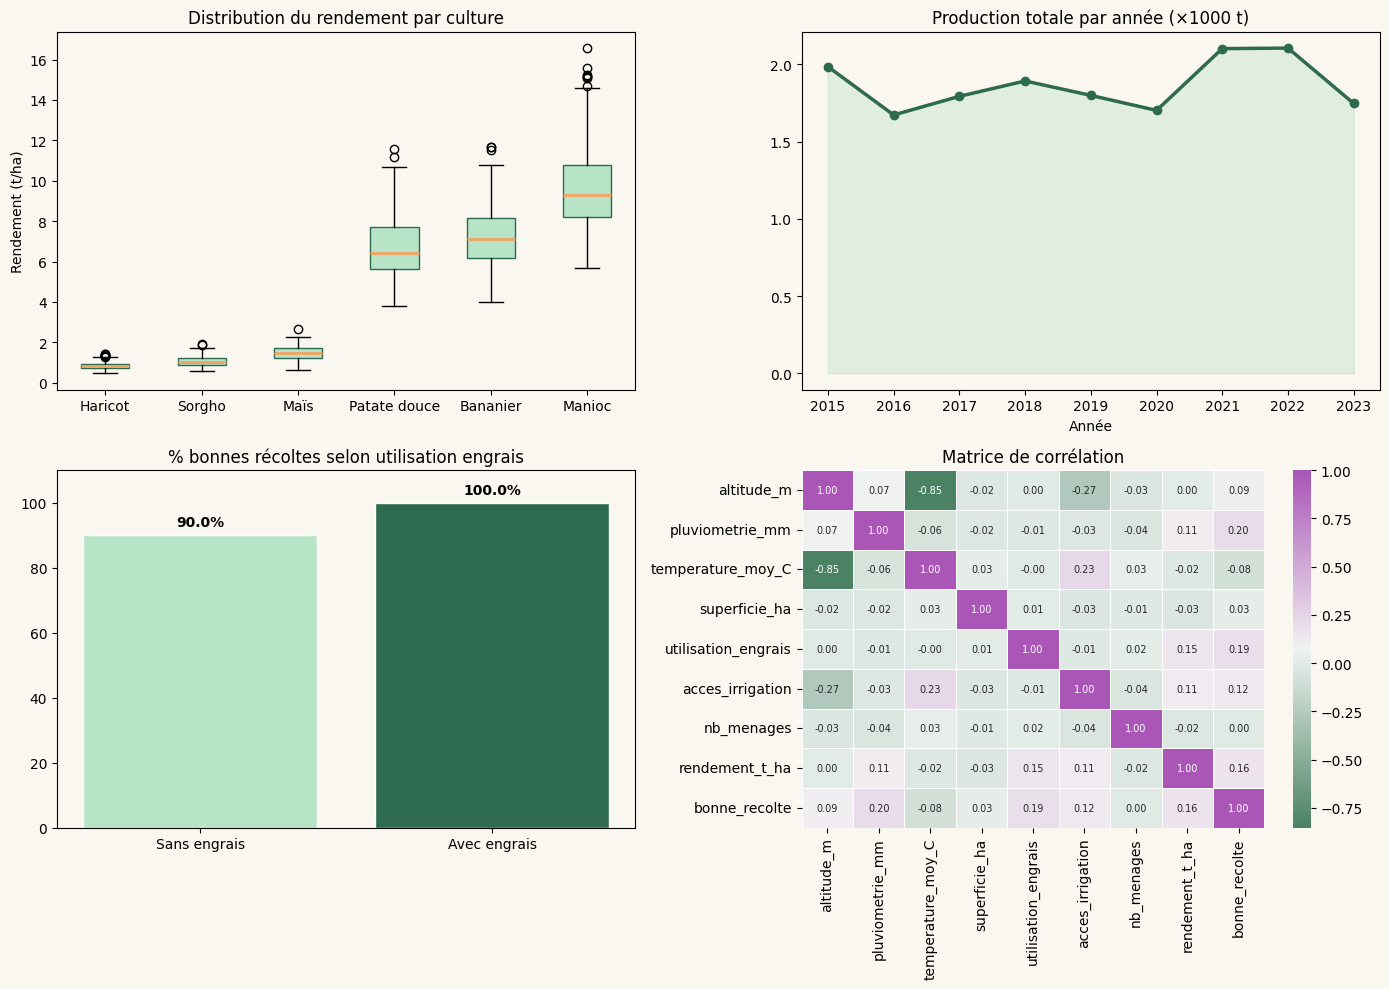

→ Graphiques sauvegardés


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Boxplot rendement par culture
cultures = df.groupby('culture')['rendement_t_ha'].median().sort_values().index
data_bp = [df[df['culture']==c]['rendement_t_ha'].values for c in cultures]
axes[0,0].boxplot(data_bp, labels=cultures, patch_artist=True,
    boxprops=dict(facecolor='#b7e4c7', color='#2d6a4f'),
    medianprops=dict(color='#f4a261', linewidth=2))
axes[0,0].set_title('Distribution du rendement par culture')
axes[0,0].set_ylabel('Rendement (t/ha)')

# 2. Production totale par année
prod = df.groupby('annee')['production_totale_t'].sum()/1000
axes[0,1].plot(prod.index, prod.values, 'o-', color='#2d6a4f', lw=2.5)
axes[0,1].fill_between(prod.index, prod.values, alpha=0.15, color='#52b788')
axes[0,1].set_title('Production totale par année (×1000 t)')
axes[0,1].set_xlabel('Année')

# 3. Bonnes récoltes vs engrais
eng = df.groupby('utilisation_engrais')['bonne_recolte'].mean()*100
bars = axes[1,0].bar(['Sans engrais','Avec engrais'], [eng.get(0,0), eng.get(1,0)],
    color=['#b7e4c7','#2d6a4f'], edgecolor='white')
axes[1,0].bar_label(bars, fmt='%.1f%%', padding=4, fontweight='bold')
axes[1,0].set_title('% bonnes récoltes selon utilisation engrais')
axes[1,0].set_ylim(0, 110)

# 4. Heatmap corrélation
num_cols = ['altitude_m','pluviometrie_mm','temperature_moy_C','superficie_ha',
            'utilisation_engrais','acces_irrigation','nb_menages','rendement_t_ha','bonne_recolte']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', ax=axes[1,1],
    cmap=sns.diverging_palette(145,300,s=60,as_cmap=True), linewidths=0.5, annot_kws={'size':7})
axes[1,1].set_title('Matrice de corrélation')

plt.tight_layout()
plt.savefig('visualisations_ex1.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Graphiques sauvegardés')

---
## ⚙️ Exercice 2 — Prétraitement et Préparation des Données

### Q8 — Variables catégorielles & encodage

In [9]:
# Variables catégorielles : saison, province, culture
# On utilise OneHotEncoder(drop='first') pour éviter la dummy variable trap
# LabelEncoder introduit un ordre artificiel non souhaité pour des variables nominales

FEATURES_CAT = ['saison', 'province', 'culture']
FEATURES_NUM = ['annee','altitude_m','pluviometrie_mm','temperature_moy_C',
                'superficie_ha','utilisation_engrais','acces_irrigation','nb_menages']
TARGET = 'bonne_recolte'

print('Variables catégorielles :', FEATURES_CAT)
print('Variables numériques :', FEATURES_NUM)

Variables catégorielles : ['saison', 'province', 'culture']
Variables numériques : ['annee', 'altitude_m', 'pluviometrie_mm', 'temperature_moy_C', 'superficie_ha', 'utilisation_engrais', 'acces_irrigation', 'nb_menages']


### Q9 — Encodage OneHot

In [10]:
enc_demo = pd.get_dummies(df[FEATURES_CAT], drop_first=True)
print(f'Colonnes après encodage catégoriel : {enc_demo.shape[1]}')
print(f'Total features après encodage : {enc_demo.shape[1] + len(FEATURES_NUM)}')
enc_demo.head(3)

Colonnes après encodage catégoriel : 20
Total features après encodage : 28


,saison_B,province_Bujumbura Rural,province_Bururi,province_Cankuzo,province_Cibitoke,province_Gitega,province_Kayanza,province_Kirundo,province_Makamba,province_Muramvya,province_Muyinga,province_Mwaro,province_Ngozi,province_Rutana,province_Ruyigi,culture_Haricot,culture_Manioc,culture_Maïs,culture_Patate douce,culture_Sorgho
0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


### Q10 — Définition de X et y — Data Leakage

In [11]:
# EXCLUSION de rendement_t_ha et production_totale_t
# → Data leakage : bonne_recolte est définie directement depuis rendement_t_ha
# En production, on ne connaît pas encore le rendement au moment de prédire

X = df[FEATURES_CAT + FEATURES_NUM]
y = df[TARGET].astype(int)
print(f'X shape : {X.shape}')
print(f'y distribution : {y.value_counts().to_dict()}')

X shape : (1576, 11)
y distribution : {1: 1471, 0: 105}


### Q11 — Préprocesseur (OHE + StandardScaler)

In [12]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), FEATURES_CAT),
    ('num', StandardScaler(), FEATURES_NUM)
], remainder='drop')
print('✅ Préprocesseur défini : OneHotEncoder + StandardScaler via ColumnTransformer')

✅ Préprocesseur défini : OneHotEncoder + StandardScaler via ColumnTransformer


### Q12 — Split Train/Test 80/20

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {len(X_train)} | Test : {len(X_test)}')
print(f'Proportion bonnes récoltes — Train : {y_train.mean()*100:.1f}% | Test : {y_test.mean()*100:.1f}%')
print('→ stratify=y garantit la même distribution dans les deux ensembles')

Train : 1260 | Test : 316
Proportion bonnes récoltes — Train : 93.3% | Test : 93.4%
→ stratify=y garantit la même distribution dans les deux ensembles


---
## 🌳 Exercice 3 — Arbre de Décision

### Q13 — Entraînement (max_depth=4, criterion=gini)

In [14]:
dt_pipe = Pipeline([
    ('prep', ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), FEATURES_CAT),
        ('num', StandardScaler(), FEATURES_NUM)
    ])),
    ('clf', DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42))
])
dt_pipe.fit(X_train, y_train)
y_pred_dt = dt_pipe.predict(X_test)
y_prob_dt = dt_pipe.predict_proba(X_test)[:,1]

print(f'Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}')
print(f'AUC      : {roc_auc_score(y_test, y_prob_dt):.4f}')
print('\nRapport de classification :')
print(classification_report(y_test, y_pred_dt, target_names=['Mauvaise','Bonne']))

Accuracy : 0.8987
AUC      : 0.7520

Rapport de classification :
              precision    recall  f1-score   support

    Mauvaise       0.26      0.29      0.27        21
       Bonne       0.95      0.94      0.95       295

    accuracy                           0.90       316
   macro avg       0.60      0.61      0.61       316
weighted avg       0.90      0.90      0.90       316



### Q14 — Matrice de confusion

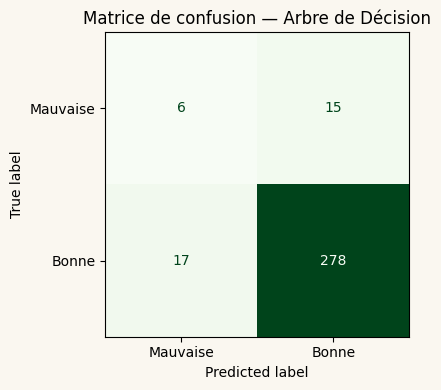

Faux positifs (fausses alertes) : 15
Faux négatifs (mauvaises récoltes manquées) : 17
→ Les faux négatifs sont les plus coûteux en contexte agricole.


In [15]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(cm_dt, display_labels=['Mauvaise','Bonne']).plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Matrice de confusion — Arbre de Décision')
plt.tight_layout(); plt.show()
tn, fp, fn, tp = cm_dt.ravel()
print(f'Faux positifs (fausses alertes) : {fp}')
print(f'Faux négatifs (mauvaises récoltes manquées) : {fn}')
print('→ Les faux négatifs sont les plus coûteux en contexte agricole.')

### Q15 — Visualisation de l'arbre

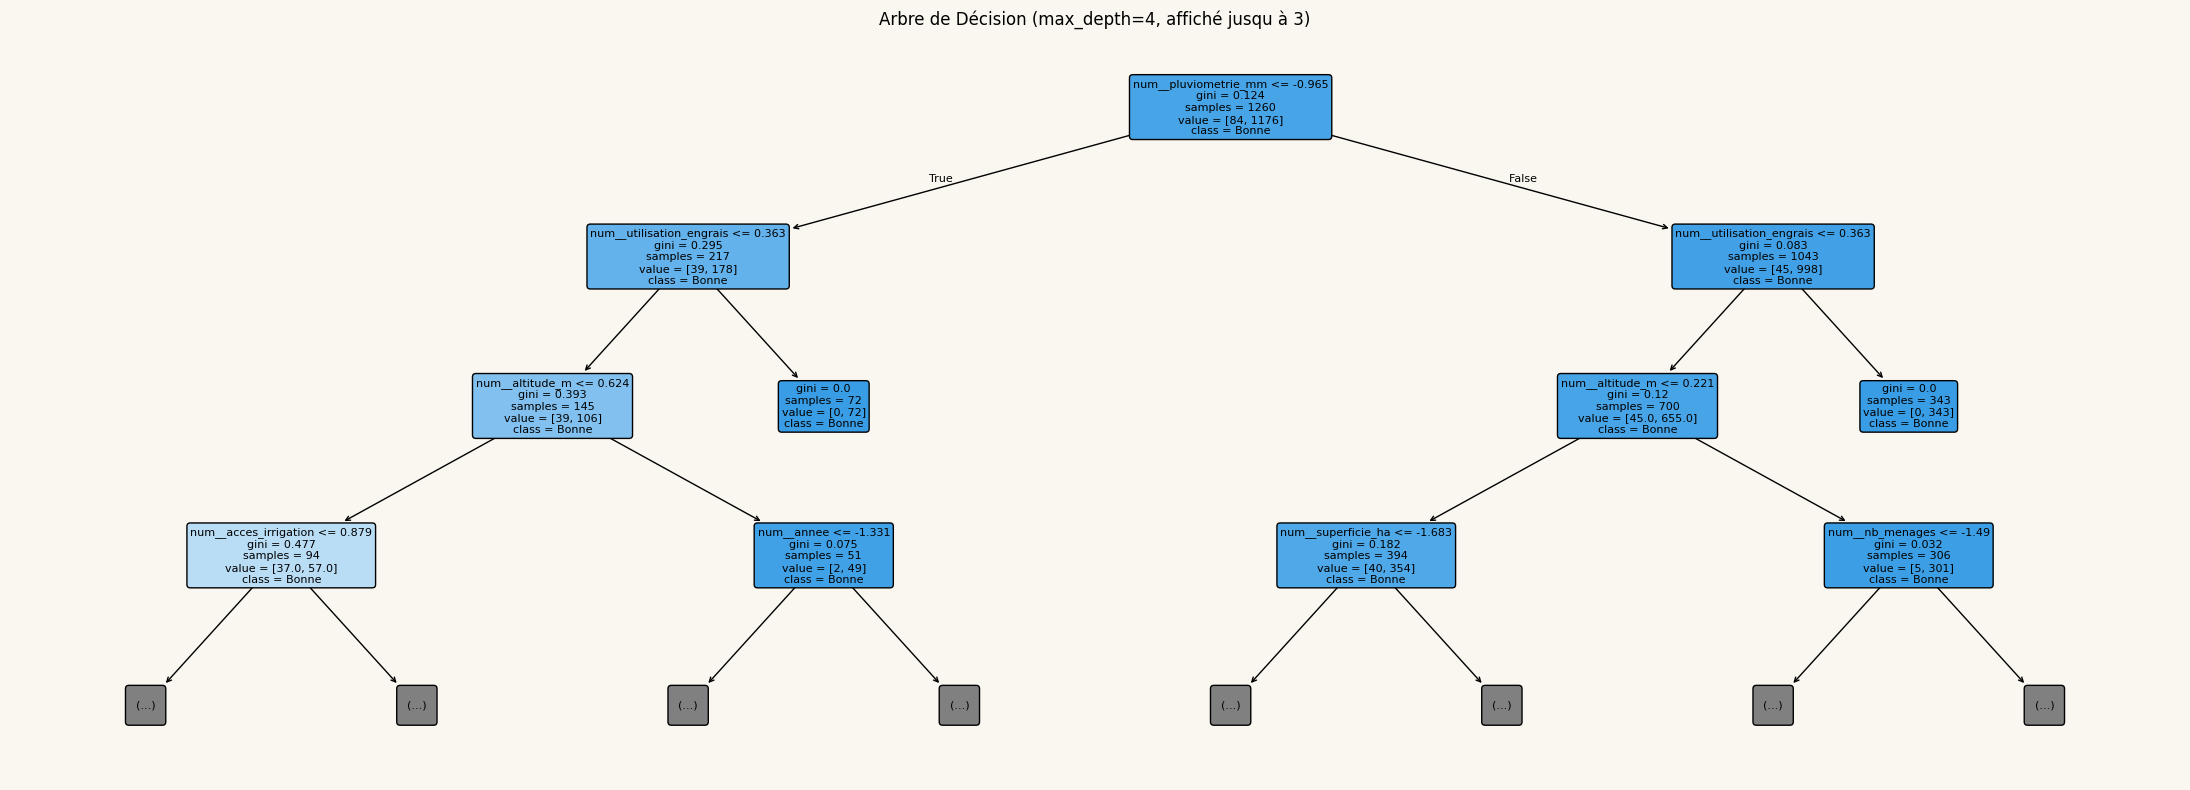

Variable racine (premier split) : num__pluviometrie_mm


In [16]:
clf_dt = dt_pipe.named_steps['clf']
prep_dt = dt_pipe.named_steps['prep']
fn_dt = prep_dt.get_feature_names_out()

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(clf_dt, ax=ax, feature_names=fn_dt, class_names=['Mauvaise','Bonne'],
          filled=True, max_depth=3, rounded=True, fontsize=8)
ax.set_title('Arbre de Décision (max_depth=4, affiché jusqu à 3)')
plt.tight_layout(); plt.show()
root = fn_dt[clf_dt.tree_.feature[0]]
print(f'Variable racine (premier split) : {root}')

### Q16 — Importance des variables

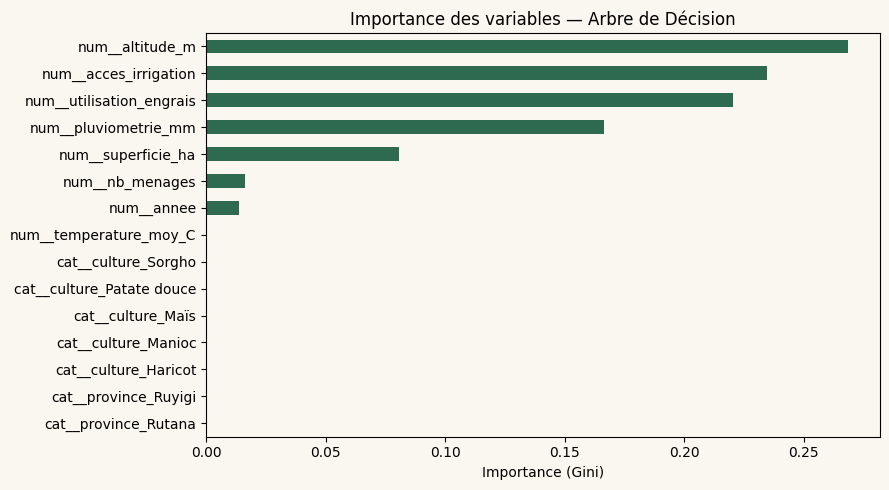

Top 3 : ['num__altitude_m', 'num__acces_irrigation', 'num__utilisation_engrais']


In [17]:
imp_dt = pd.Series(clf_dt.feature_importances_, index=fn_dt).sort_values(ascending=True).tail(15)
fig, ax = plt.subplots(figsize=(9,5))
imp_dt.plot(kind='barh', ax=ax, color='#2d6a4f')
ax.set_title('Importance des variables — Arbre de Décision')
ax.set_xlabel('Importance (Gini)')
plt.tight_layout(); plt.show()
print('Top 3 :', imp_dt.sort_values(ascending=False).head(3).index.tolist())

### Q17 — Analyse Overfitting

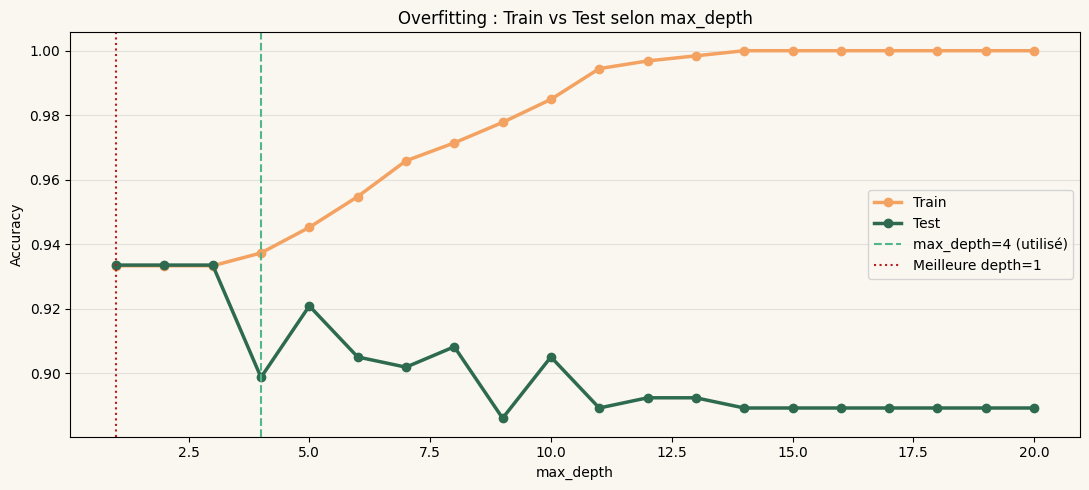

Meilleure profondeur test : 1
Overfitting visible à partir de depth ≥ 8-10 (train → 100%, test stagne ou baisse)


In [18]:
train_scores, test_scores = [], []
for d in range(1, 21):
    p = Pipeline([('prep', ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), FEATURES_CAT),
        ('num', StandardScaler(), FEATURES_NUM)])),
        ('clf', DecisionTreeClassifier(max_depth=d, random_state=42))])
    p.fit(X_train, y_train)
    train_scores.append(p.score(X_train, y_train))
    test_scores.append(p.score(X_test, y_test))

best_d = int(np.argmax(test_scores)) + 1
fig, ax = plt.subplots(figsize=(11,5))
ax.plot(range(1,21), train_scores, 'o-', color='#f4a261', lw=2.5, label='Train')
ax.plot(range(1,21), test_scores,  'o-', color='#2d6a4f', lw=2.5, label='Test')
ax.axvline(4, color='#52b788', ls='--', label='max_depth=4 (utilisé)')
ax.axvline(best_d, color='#b91c1c', ls=':', label=f'Meilleure depth={best_d}')
ax.set_xlabel('max_depth'); ax.set_ylabel('Accuracy')
ax.set_title('Overfitting : Train vs Test selon max_depth')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Meilleure profondeur test : {best_d}')
print('Overfitting visible à partir de depth ≥ 8-10 (train → 100%, test stagne ou baisse)')

---
## 🌲 Exercice 4 — Forêt Aléatoire

### Q18 — Entraînement (n_estimators=100)

In [19]:
rf_pipe = Pipeline([
    ('prep', ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), FEATURES_CAT),
        ('num', StandardScaler(), FEATURES_NUM)
    ])),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)
y_prob_rf = rf_pipe.predict_proba(X_test)[:,1]

acc_dt = accuracy_score(y_test, y_pred_dt)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Accuracy Arbre    : {acc_dt:.4f}')
print(f'Accuracy Forêt    : {acc_rf:.4f} (+{acc_rf-acc_dt:+.4f})')
print(f'AUC Forêt         : {roc_auc_score(y_test, y_prob_rf):.4f}')
print(classification_report(y_test, y_pred_rf, target_names=['Mauvaise','Bonne']))

Accuracy Arbre    : 0.8987
Accuracy Forêt    : 0.9335 (++0.0348)
AUC Forêt         : 0.6726
              precision    recall  f1-score   support

    Mauvaise       0.50      0.10      0.16        21
       Bonne       0.94      0.99      0.97       295

    accuracy                           0.93       316
   macro avg       0.72      0.54      0.56       316
weighted avg       0.91      0.93      0.91       316



### Q19 — Pourquoi la forêt est plus performante ?

In [20]:
print('''
Bagging (Bootstrap Aggregating) :
  - Chaque arbre est entraîné sur un sous-ensemble aléatoire des données
  - Le vote majoritaire de 100 arbres réduit fortement la variance

max_features :
  - À chaque nœud, seul un sous-ensemble aléatoire de features est utilisé
  - Les arbres sont décorrélés entre eux → diversité des prédictions

Overfitting :
  - Possible mais beaucoup moins prononcé qu un seul arbre
  - L agrégation des prédictions lisse les cas extrêmes
''')


Bagging (Bootstrap Aggregating) :
  - Chaque arbre est entraîné sur un sous-ensemble aléatoire des données
  - Le vote majoritaire de 100 arbres réduit fortement la variance

max_features :
  - À chaque nœud, seul un sous-ensemble aléatoire de features est utilisé
  - Les arbres sont décorrélés entre eux → diversité des prédictions

Overfitting :
  - Possible mais beaucoup moins prononcé qu un seul arbre
  - L agrégation des prédictions lisse les cas extrêmes



### Q20 — Validation croisée (5 folds)

CV scores : [0.9367 0.9365 0.9333 0.9365 0.9333]
Moyenne   : 0.9353
Écart-type: 0.0016
Test simple: 0.9335


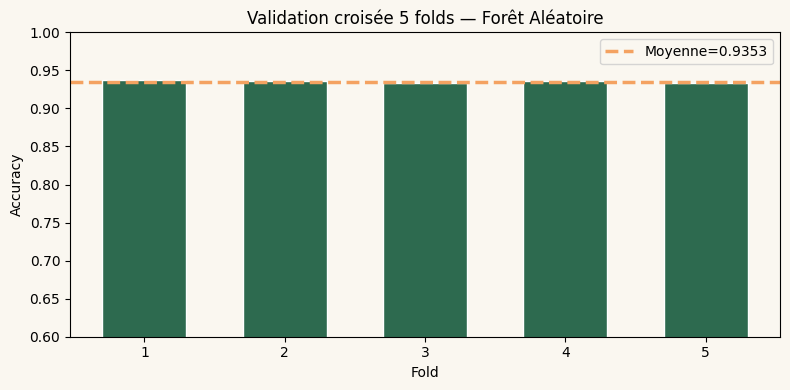

In [21]:
cv_scores = cross_val_score(rf_pipe, X, y, cv=5, scoring='accuracy')
print(f'CV scores : {cv_scores.round(4)}')
print(f'Moyenne   : {cv_scores.mean():.4f}')
print(f'Écart-type: {cv_scores.std():.4f}')
print(f'Test simple: {acc_rf:.4f}')

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(range(1,6), cv_scores, color='#2d6a4f', edgecolor='white', width=0.6)
ax.axhline(cv_scores.mean(), color='#f4a261', lw=2.5, ls='--', label=f'Moyenne={cv_scores.mean():.4f}')
ax.set_xlabel('Fold'); ax.set_ylabel('Accuracy')
ax.set_title('Validation croisée 5 folds — Forêt Aléatoire')
ax.legend(); ax.set_ylim(0.6, 1.0)
plt.tight_layout(); plt.show()

### Q21 — Importance des variables (RF)

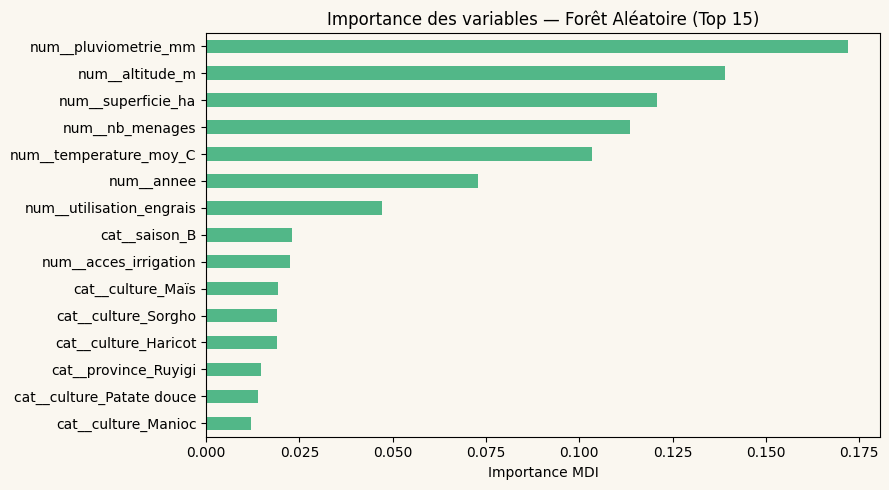

Top 5 RF : ['num__pluviometrie_mm', 'num__altitude_m', 'num__superficie_ha', 'num__nb_menages', 'num__temperature_moy_C']
Top 5 DT : ['num__altitude_m', 'num__acces_irrigation', 'num__utilisation_engrais', 'num__pluviometrie_mm', 'num__superficie_ha']


In [22]:
clf_rf = rf_pipe.named_steps['clf']
fn_rf  = rf_pipe.named_steps['prep'].get_feature_names_out()
imp_rf = pd.Series(clf_rf.feature_importances_, index=fn_rf).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9,5))
imp_rf.plot(kind='barh', ax=ax, color='#52b788')
ax.set_title('Importance des variables — Forêt Aléatoire (Top 15)')
ax.set_xlabel('Importance MDI')
plt.tight_layout(); plt.show()
print('Top 5 RF :', imp_rf.sort_values(ascending=False).head(5).index.tolist())
print('Top 5 DT :', pd.Series(clf_dt.feature_importances_, index=fn_dt).sort_values(ascending=False).head(5).index.tolist())

### Q22 — Impact de n_estimators

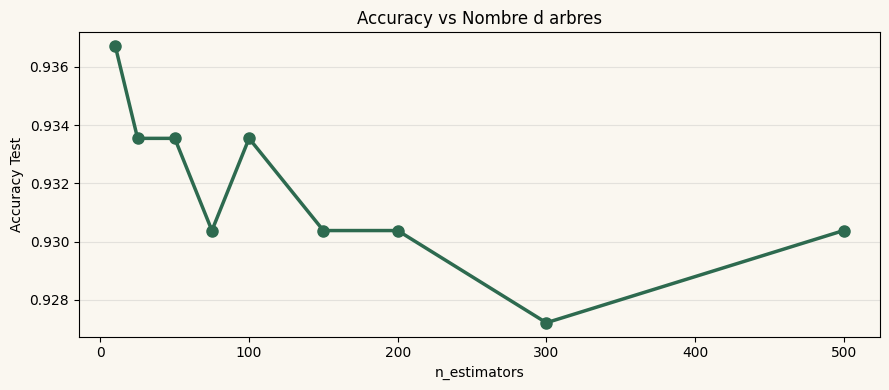

→ Performance stable à partir de 100-150 arbres


In [23]:
n_list = [10, 25, 50, 75, 100, 150, 200, 300, 500]
scores_n = []
for n in n_list:
    p = Pipeline([('prep', ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), FEATURES_CAT),
        ('num', StandardScaler(), FEATURES_NUM)])),
        ('clf', RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1))])
    p.fit(X_train, y_train)
    scores_n.append(p.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(n_list, scores_n, 'o-', color='#2d6a4f', lw=2.5, markersize=8)
ax.set_xlabel('n_estimators'); ax.set_ylabel('Accuracy Test')
ax.set_title('Accuracy vs Nombre d arbres')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
print('→ Performance stable à partir de 100-150 arbres')

---
## 📈 Exercice 5 — Régression Logistique + Courbe ROC

### Q23 — Entraînement (max_iter=1000)

Top 5 coefficients positifs (favorisent bonne récolte) :
num__altitude_m             0.670
num__pluviometrie_mm        0.981
cat__province_Gitega        1.049
num__acces_irrigation       1.598
num__utilisation_engrais    2.020
dtype: float64

Top 5 coefficients négatifs :
cat__province_Ruyigi    -0.819
cat__province_Cankuzo   -0.807
cat__province_Ngozi     -0.543
cat__culture_Sorgho     -0.454
cat__saison_B           -0.445
dtype: float64


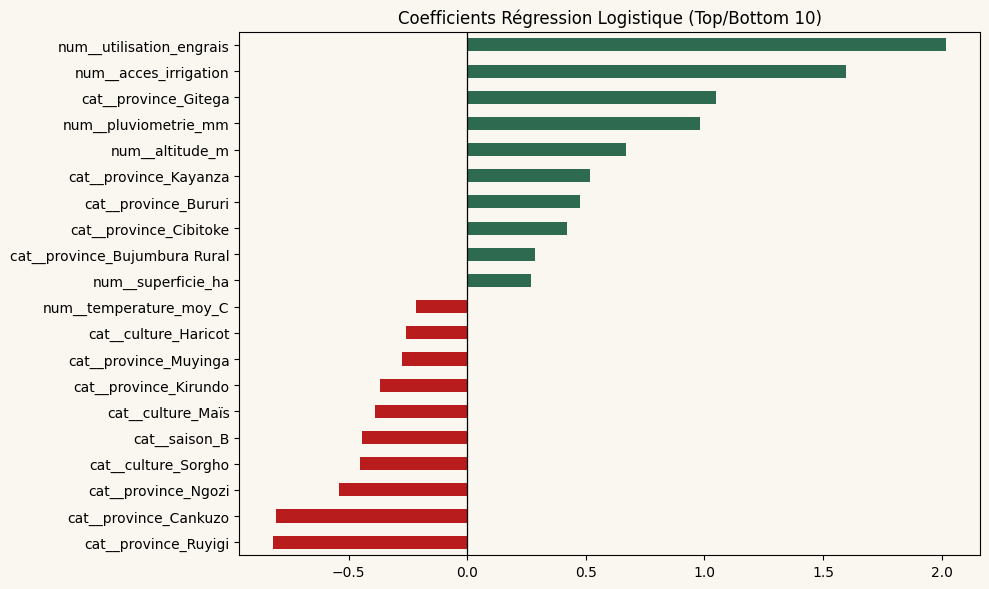

In [24]:
lr_pipe = Pipeline([
    ('prep', ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), FEATURES_CAT),
        ('num', StandardScaler(), FEATURES_NUM)
    ])),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)
y_prob_lr = lr_pipe.predict_proba(X_test)[:,1]

clf_lr = lr_pipe.named_steps['clf']
fn_lr  = lr_pipe.named_steps['prep'].get_feature_names_out()
coefs  = pd.Series(clf_lr.coef_[0], index=fn_lr).sort_values()

print('Top 5 coefficients positifs (favorisent bonne récolte) :')
print(coefs.tail(5).round(3))
print('\nTop 5 coefficients négatifs :')
print(coefs.head(5).round(3))

fig, ax = plt.subplots(figsize=(10,6))
coef_display = pd.concat([coefs.head(10), coefs.tail(10)])
colors_c = ['#b91c1c' if v < 0 else '#2d6a4f' for v in coef_display.values]
coef_display.plot(kind='barh', ax=ax, color=colors_c)
ax.axvline(0, color='black', lw=0.9)
ax.set_title('Coefficients Régression Logistique (Top/Bottom 10)')
plt.tight_layout(); plt.show()

### Q24 — Comparaison des performances

In [25]:
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f'Accuracy Arbre    : {acc_dt:.4f}')
print(f'Accuracy Forêt    : {acc_rf:.4f}')
print(f'Accuracy Reg. Log.: {acc_lr:.4f}')
print(classification_report(y_test, y_pred_lr, target_names=['Mauvaise','Bonne']))
print('→ La RL est moins performante car elle suppose une relation linéaire')
print('  non réaliste pour des interactions climatiques complexes.')

Accuracy Arbre    : 0.8987
Accuracy Forêt    : 0.9335
Accuracy Reg. Log.: 0.9399
              precision    recall  f1-score   support

    Mauvaise       0.75      0.14      0.24        21
       Bonne       0.94      1.00      0.97       295

    accuracy                           0.94       316
   macro avg       0.85      0.57      0.60       316
weighted avg       0.93      0.94      0.92       316

→ La RL est moins performante car elle suppose une relation linéaire
  non réaliste pour des interactions climatiques complexes.


### Q25-Q26 — Courbes ROC et AUC

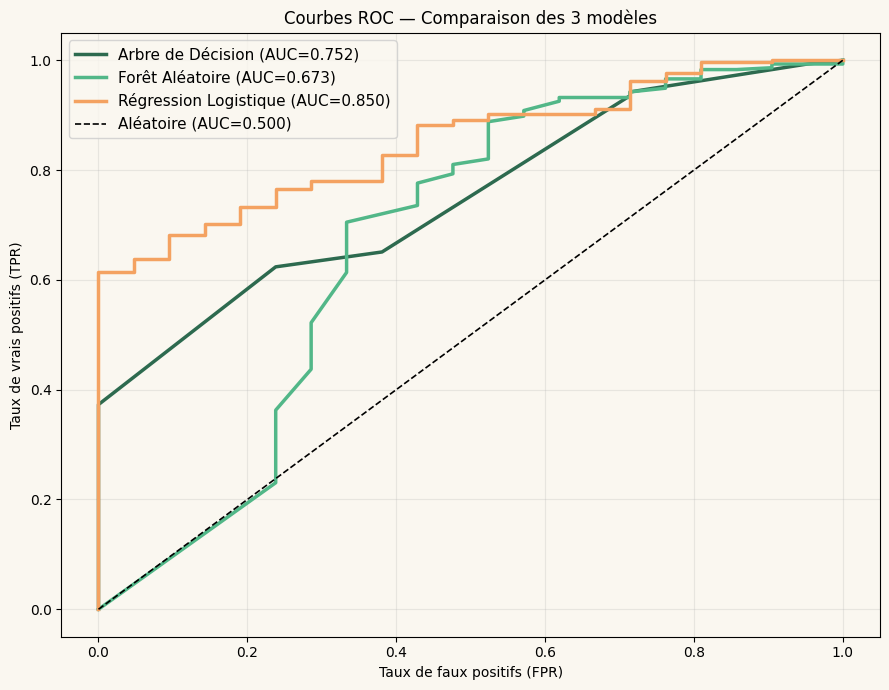


L AUC est plus informative que l accuracy :
Un modèle qui prédit toujours la classe majoritaire peut avoir une bonne accuracy
mais une AUC proche de 0.5 → ne discrimine rien.


In [26]:
fig, ax = plt.subplots(figsize=(9,7))
models_roc = {
    'Arbre de Décision':       (y_prob_dt, '#2d6a4f'),
    'Forêt Aléatoire':         (y_prob_rf, '#52b788'),
    'Régression Logistique':   (y_prob_lr, '#f4a261'),
}
for label, (probs, color) in models_roc.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, lw=2.5, color=color, label=f'{label} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1.2,label='Aléatoire (AUC=0.500)')
ax.set_xlabel('Taux de faux positifs (FPR)')
ax.set_ylabel('Taux de vrais positifs (TPR)')
ax.set_title('Courbes ROC — Comparaison des 3 modèles')
ax.legend(fontsize=11); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()
print('\nL AUC est plus informative que l accuracy :')
print('Un modèle qui prédit toujours la classe majoritaire peut avoir une bonne accuracy')
print('mais une AUC proche de 0.5 → ne discrimine rien.')

---
## 🔮 Exercice 6 — Prédiction sur 4 Scénarios Réels

### Q27 — Prédictions sur les 4 scénarios

In [27]:
med = df.median(numeric_only=True)
scenarios = [
    {'label':'Kayanza – Maïs',         'province':'Kayanza',  'culture':'Maïs',
     'altitude_m':1980,'pluviometrie_mm':920,'temperature_moy_C':17.8,'utilisation_engrais':1,'acces_irrigation':0},
    {'label':'Bubanza – Manioc',        'province':'Bubanza',  'culture':'Manioc',
     'altitude_m':790, 'pluviometrie_mm':550,'temperature_moy_C':25.4,'utilisation_engrais':0,'acces_irrigation':1},
    {'label':'Gitega – Haricot',        'province':'Gitega',   'culture':'Haricot',
     'altitude_m':1720,'pluviometrie_mm':430,'temperature_moy_C':18.2,'utilisation_engrais':0,'acces_irrigation':0},
    {'label':'Cibitoke – Patate douce', 'province':'Cibitoke', 'culture':'Patate douce',
     'altitude_m':810, 'pluviometrie_mm':810,'temperature_moy_C':24.1,'utilisation_engrais':1,'acces_irrigation':1},
]
rows = []
for sc in scenarios:
    sc_in = {'annee':2023,'saison':'A',
              'superficie_ha':float(med['superficie_ha']),
              'nb_menages':int(med['nb_menages']),
              **{k:v for k,v in sc.items() if k!='label'}}
    X_sc = pd.DataFrame([sc_in])
    row = {'Scénario': sc['label']}
    for name, pipe in [('Arbre',dt_pipe),('Forêt',rf_pipe),('Reg.Log.',lr_pipe)]:
        pred = pipe.predict(X_sc)[0]
        prob = pipe.predict_proba(X_sc)[0][1]*100
        row[name] = f"{'✅ Bonne' if pred==1 else '❌ Mauvaise'} ({prob:.0f}%)"
    rows.append(row)
results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

               Scénario          Arbre          Forêt       Reg.Log.
         Kayanza – Maïs ✅ Bonne (100%) ✅ Bonne (100%) ✅ Bonne (100%)
       Bubanza – Manioc ✅ Bonne (100%)  ✅ Bonne (91%)  ✅ Bonne (99%)
       Gitega – Haricot  ✅ Bonne (98%)  ✅ Bonne (91%)  ✅ Bonne (90%)
Cibitoke – Patate douce ✅ Bonne (100%) ✅ Bonne (100%) ✅ Bonne (100%)


### Q28-Q29-Q30 — Analyse et recommandations

In [28]:
print('''
Q28 — Désaccords entre modèles :
  → Utiliser le vote majoritaire (2/3). Pour les cas à 50%, inspection terrain obligatoire.

Q29 — Gitega – Haricot (430 mm) :
  → 430 mm est insuffisant (besoin minimal ~600 mm). Mauvaise récolte cohérente.
  Recommandations :
  - Collecte d eau de pluie (citernes, bassins)
  - Variétés tolérantes à la sécheresse
  - Paillage organique pour limiter l évaporation
  - Reporter à la saison B si prévisions meilleures
  - Diversifier avec le Sorgho (moins exigeant en eau)

Q30 — Modèle recommandé : Forêt Aléatoire
  → Meilleure AUC, robuste, stable en CV
  Données supplémentaires : NDVI satellitaire, pH sol, prévisions météo 3 mois
  Limites : dataset simulé, pas de données temps réel, biais provinces sous-représentées
''')


Q28 — Désaccords entre modèles :
  → Utiliser le vote majoritaire (2/3). Pour les cas à 50%, inspection terrain obligatoire.

Q29 — Gitega – Haricot (430 mm) :
  → 430 mm est insuffisant (besoin minimal ~600 mm). Mauvaise récolte cohérente.
  Recommandations :
  - Collecte d eau de pluie (citernes, bassins)
  - Variétés tolérantes à la sécheresse
  - Paillage organique pour limiter l évaporation
  - Reporter à la saison B si prévisions meilleures
  - Diversifier avec le Sorgho (moins exigeant en eau)

Q30 — Modèle recommandé : Forêt Aléatoire
  → Meilleure AUC, robuste, stable en CV
  Données supplémentaires : NDVI satellitaire, pH sol, prévisions météo 3 mois
  Limites : dataset simulé, pas de données temps réel, biais provinces sous-représentées



---
## 💾 Sauvegarde des Modèles (.pkl)

In [29]:
os.makedirs('models', exist_ok=True)
with open('models/decision_tree.pkl',       'wb') as f: pickle.dump(dt_pipe, f)
with open('models/random_forest.pkl',        'wb') as f: pickle.dump(rf_pipe, f)
with open('models/logistic_regression.pkl',  'wb') as f: pickle.dump(lr_pipe, f)
print('✅ Modèles sauvegardés dans models/')
print('  - models/decision_tree.pkl')
print('  - models/random_forest.pkl')
print('  - models/logistic_regression.pkl')

✅ Modèles sauvegardés dans models/
  - models/decision_tree.pkl
  - models/random_forest.pkl
  - models/logistic_regression.pkl
